In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
USE_WANDB = True
# Used across all figures so the reader can trust 'same color = same env'.
PALETTE = ['mediumvioletred', 'gold', 'darkorange', 'deepskyblue', 'slateblue', 'mediumorchid', 'forestgreen', 'darkred', 'cadetblue']

# Each env gets a fixed color across every plot it appears in.
ENV_COLORS = {
    'puzzle-3x3-oraclerep':                    'mediumvioletred',
    'puzzle-4x4-oraclerep':          'darkorange',
    'humanoidmaze-medium-oraclerep': 'deepskyblue',
    'humanoidmaze-large-oraclerep':  'slateblue',
    'puzzle-4x5':                     'gold',
    'puzzle-4x6':                     'mediumorchid',
    'humanoidmaze-giant':             'forestgreen',
    'pointmaze-teleport-navigate':    'darkred',
    'antmaze-large-stitch ':          'cadetblue',
}

TASK_COLORS = plt.cm.viridis(np.linspace(0.15, 0.85, 5))

PAIR_COLORS = ['mediumvioletred', 'darkorange']

BASE_FONTSIZE = 16
plt.rcParams.update({
    'font.size':       BASE_FONTSIZE,
    'axes.titlesize':  BASE_FONTSIZE + 1,
    'axes.labelsize':  BASE_FONTSIZE,
    'xtick.labelsize': BASE_FONTSIZE - 1,
    'ytick.labelsize': BASE_FONTSIZE - 1,
    'legend.fontsize': BASE_FONTSIZE - 1,
    'figure.titlesize': BASE_FONTSIZE + 2,
})

In [ ]:
# Fall back to hard-coded if no wandb
hummaze_giant_expectile_seven = [0, 6, 18, 40, 48]
hummaze_giant_expectile_five  = [0, 0, 0, 4, 0]

puzzle_4x4_trajgoal_lambda_two = [0, 36, 54, 46, 44]
puzzle_4x4_randgoal            = [0, 18, 10, 12, 2]
puzzle_4x4_lambda_0            = [0, 18, 16, 10, 8]

times = [0, 0.25, 0.5, 0.75, 1]

## Optional: pull ablation curves directly from wandb

Skip if using hard-coded values (`USE_WANDB = False`).

Otherwise:
1. `pip install wandb` and run `wandb login` once in a terminal.
2. Fill in the run IDs below for each ablation cell. Run IDs are the 8-character slugs in the wandb URL (e.g. `4wuityz1` from `https://wandb.ai/.../runs/4wuityz1`).
3. Set `USE_WANDB = True` in the imports cell.
4. Run the pull cell, then the plotting cell.

In [ ]:
# wandb config
ENTITY  = 'ljcho2005-princeton-university'
PROJECT = 'OGBench'

import os, pickle, hashlib
from pathlib import Path

CACHE_DIR = Path('./wandb_cache')
CACHE_DIR.mkdir(exist_ok=True)

# Set FORCE_REFETCH = True to ignore the cache and re-pull everything from wandb.
# Useful if a run's metrics changed (e.g. you re-ran with the same ID, or new logging was added).
# Otherwise leave False — cached pulls are instant on re-runs.
FORCE_REFETCH = False


# Fill in run IDs once you have them. Leave empty strings to fall back to Luke's hand-coded values.
ABLATION_RUN_IDS = {
    'hummaze_giant_expectile_seven': '',           # humanoidmaze-giant, expectile=0.7 (Tate's)
    'hummaze_giant_expectile_five':  '',           # humanoidmaze-giant, expectile=0.5 (Tate's)
    'puzzle_4x4_trajgoal_lambda_two': '',          # puzzle-4x4, in-traj, lambda=2 (Tate's, baseline reused in 2 panels)
    'puzzle_4x4_randgoal':           '',           # puzzle-4x4, random goals (Tate's)
    'puzzle_4x4_lambda_0':           '0doklrrb',   # puzzle-4x4, in-traj, lambda=0 (Veronica's)
}

SAMPLE_STEPS_M = [0.0, 0.25, 0.5, 0.75, 1.0]


def _cache_path(run_id, metric):
    """Deterministic cache filename per (run_id, metric) pair."""
    h = hashlib.md5(metric.encode()).hexdigest()[:8]
    return CACHE_DIR / f'{run_id}__{h}.pkl'


def fetch_run_curve(run_id, metric='evaluation/overall_success'):
    """Pull one run's curve from wandb, with on-disk caching.
    Returns (steps_array, vals_array) in raw units, or (None, None) on failure.

    Cache behaviour:
      - First call for a (run_id, metric) hits wandb and saves the result to disk.
      - Subsequent calls load instantly from disk.
      - Set FORCE_REFETCH = True (above) to bypass cache for one session.
      - Delete files in ./wandb_cache/ to invalidate specific runs.
    """
    if not run_id:
        return None, None

    cache_file = _cache_path(run_id, metric)
    if cache_file.exists() and not FORCE_REFETCH:
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    import wandb
    api = wandb.Api()
    run = api.run(f'{ENTITY}/{PROJECT}/{run_id}')
    df = run.history(keys=['_step', metric], samples=500, pandas=True)
    if df.empty:
        result = (None, None)
    else:
        df = df.dropna(subset=[metric]).sort_values('_step')
        result = (df['_step'].values, df[metric].values) if not df.empty else (None, None)

    # Cache the result (even None,None — saves us from re-trying broken pulls)
    with open(cache_file, 'wb') as f:
        pickle.dump(result, f)
    return result


def sample_at_checkpoints(steps, vals, checkpoints_m, scale=100):
    """Sample (steps, vals) at the requested checkpoint step counts (in millions).
    Uses nearest-step matching. Multiplies by `scale` (default 100) to convert
    success_rate -> percentage to match the hand-coded format."""
    if steps is None:
        return [0] * len(checkpoints_m)
    out = []
    for cp_m in checkpoints_m:
        target = cp_m * 1_000_000
        if target == 0:
            out.append(0)
            continue
        idx = int(np.argmin(np.abs(steps - target)))
        out.append(float(vals[idx]) * scale)
    return out


def clear_cache(run_id=None):
    """Delete cached pulls. Call clear_cache() to wipe everything,
    or clear_cache('4wuityz1') to invalidate one run."""
    if run_id is None:
        for f in CACHE_DIR.glob('*.pkl'):
            f.unlink()
        print(f'Cleared all cached runs from {CACHE_DIR}')
    else:
        deleted = 0
        for f in CACHE_DIR.glob(f'{run_id}__*.pkl'):
            f.unlink()
            deleted += 1
        print(f'Cleared {deleted} cached metrics for run {run_id}')

In [ ]:
# Run this cell to pull from wandb. Only does anything if USE_WANDB=True
# AND you've populated ABLATION_RUN_IDS above.
if USE_WANDB:
    pulled = {}
    for var_name, rid in ABLATION_RUN_IDS.items():
        if not rid:
            print(f'  [skip] {var_name}: no run ID, will use hand-coded value')
            continue
        steps, vals = fetch_run_curve(rid)
        sampled = sample_at_checkpoints(steps, vals, SAMPLE_STEPS_M)
        pulled[var_name] = sampled
        print(f'  [ok]   {var_name} ({rid}): {sampled}')

    # Overwrite the global variables for any successfully-pulled run.
    # Hand-coded values from the cell above stay in place for any var without a run ID.
    globals().update(pulled)
    times = SAMPLE_STEPS_M
    print(f'\nUsing wandb data for: {list(pulled.keys())}')
else:
    print('USE_WANDB=False, using hand-coded values from the cell above')

  [skip] hummaze_giant_expectile_seven: no run ID, will use hand-coded value
  [skip] hummaze_giant_expectile_five: no run ID, will use hand-coded value
  [skip] puzzle_4x4_trajgoal_lambda_two: no run ID, will use hand-coded value
  [skip] puzzle_4x4_randgoal: no run ID, will use hand-coded value
  [ok]   puzzle_4x4_lambda_0 (0doklrrb): [0, 18.0, 15.999999999999998, 10.0, 8.0]

Using wandb data for: ['puzzle_4x4_lambda_0']


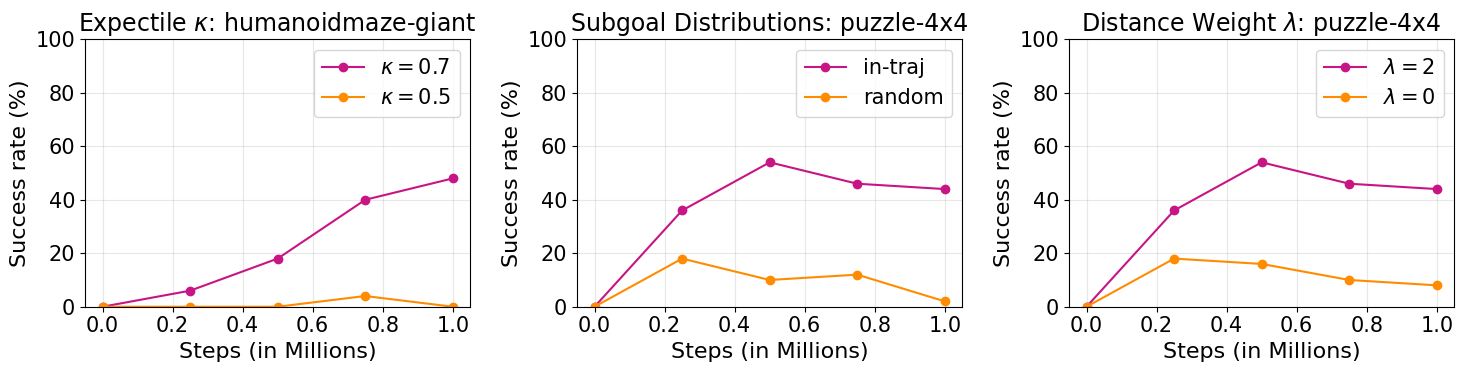

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (times, hummaze_giant_expectile_seven, hummaze_giant_expectile_five,
     r'Expectile $\kappa$: humanoidmaze-giant', (r'$\kappa=0.7$', r'$\kappa=0.5$')),
    (times, puzzle_4x4_trajgoal_lambda_two, puzzle_4x4_randgoal,
     'Subgoal Distributions: puzzle-4x4', ('in-traj', 'random')),
    (times, puzzle_4x4_trajgoal_lambda_two, puzzle_4x4_lambda_0,
     r'Distance Weight $\lambda$: puzzle-4x4', (r'$\lambda=2$', r'$\lambda=0$')),
]

for ax, (t, y1, y2, title, lbls) in zip(axes, datasets):
    ax.plot(t, y1, marker='o', label=lbls[0], color=PAIR_COLORS[0])
    ax.plot(t, y2, marker='o', label=lbls[1], color=PAIR_COLORS[1])
    ax.set_title(title)
    ax.set_xlabel('Steps (in Millions)')
    ax.set_ylabel('Success rate (%)')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('ablations.pdf', bbox_inches='tight')
plt.show()

## Main results: 4 OGBench environments

Same style as the ablation plot above. Pulls full per-step success curves from wandb for the 4 main eval runs. If you'd rather hand-code values (e.g. for offline use), set `MAIN_RUNS_USE_HANDCODED = True` and fill in the lists below.

In [ ]:
# Main eval runs
MAIN_RUN_IDS = {
    'puzzle-3x3-oraclerep':          'l4xieaeb',
    'puzzle-4x4-oraclerep':          '2a0c1rbg',
    'humanoidmaze-medium-oraclerep': '4q1tqd9c',
    'humanoidmaze-large-oraclerep':  '1tmw4vry',
}

LONG_RUN_IDS = {
    'puzzle-4x5':                     '1nu92u1b',
    'puzzle-4x6':                     '4wuityz1',
    'humanoidmaze-giant':             'l6kekdsq'
}

NEW_RUN_IDS = {
    'pointmaze-teleport-navigate':    'ecj8fid2',
    'antmaze-large-stitch ':          '4ha1lat2'
}

# Toggle if you want to use hand-coded values instead of pulling from wandb.
MAIN_RUNS_USE_HANDCODED = False

# Hard-coded fallback
# Only used if MAIN_RUNS_USE_HANDCODED = True.
MAIN_HANDCODED = {
    'puzzle-3x3-oraclerep':          [0, 100,  96,  100,  100],
    'puzzle-4x4-oraclerep':          [0, 40, 54, 50, 60],
    'humanoidmaze-medium-oraclerep': [0, 35, 38, 48, 44],
    'humanoidmaze-large-oraclerep':  [0, 2,  10, 10, 8],
}

In [ ]:
# Pulls full per-step curves so the plot can be smooth, not just 5 checkpoints.
# Falls back to hand-coded values if MAIN_RUNS_USE_HANDCODED=True, if a run ID is empty,
# or if the wandb pull fails for any reason (no wandb installed, no internet, bad ID).
def get_run_curves(run_id_dict, handcoded=False, handcoded_metrics = None):
  curves = {}
  if handcoded:
      for label, vals in handcoded_metrics.items():
          curves[label] = (np.array(SAMPLE_STEPS_M), np.array(vals))
      print(f'Using hand-coded values for {len(main_curves)} main runs')
  else:
      for label, rid in run_id_dict.items():
          steps, vals = (None, None)
          if rid:
              try:
                  steps, vals = fetch_run_curve(rid, metric='evaluation/overall_success')
              except Exception as e:
                  print(f'  [error] {label} ({rid}): {e}')
          if steps is None:
              fallback = handcoded_metrics.get(label)
              if fallback is not None:
                  curves[label] = (np.array(SAMPLE_STEPS_M), np.array(fallback))
                  print(f'  [fallback] {label}: using hand-coded values')
          else:
              # Convert to (millions of steps, percentage) to match units
              curves[label] = (steps / 1e6, vals * 100)
              print(f'  [ok]   {label} ({rid}): {len(steps)} eval points, final={vals[-1]*100:.1f}%')

  return curves

In [ ]:
def plot_curves(curves, title, filename, handcoded=False):
  fig, ax = plt.subplots(figsize=(7, 4))

  for label, (steps_m, vals) in curves.items():
      if not handcoded:
        steps_m = np.insert(steps_m, 0, 0)
        vals = np.insert(vals, 0, 0)

      marker = 'o' if len(steps_m) <= 10 else None
      color = ENV_COLORS.get(label)  # falls back to matplotlib default if unmapped
      ax.plot(steps_m, vals, marker=marker, label=label, color=color)

  ax.set_title(title)
  ax.set_xlabel('Steps (in Millions)')
  ax.set_ylabel('Success rate (%)')
  ax.set_ylim(-5, 105)  # Adjusted y-axis limits for better visibility
  ax.grid(True, alpha=0.3)

  # Move legend outside the figure
  handles, labels = ax.get_legend_handles_labels()
  fig.legend(handles, labels, loc='center left',
            bbox_to_anchor=(1.05, 0.5), frameon=False)

  plt.tight_layout()
  plt.savefig(filename, bbox_inches='tight')
  plt.show()

  [ok]   puzzle-3x3-oraclerep (l4xieaeb): 4 eval points, final=100.0%
  [ok]   puzzle-4x4-oraclerep (2a0c1rbg): 4 eval points, final=60.0%
  [ok]   humanoidmaze-medium-oraclerep (4q1tqd9c): 4 eval points, final=44.0%
  [ok]   humanoidmaze-large-oraclerep (1tmw4vry): 4 eval points, final=8.0%


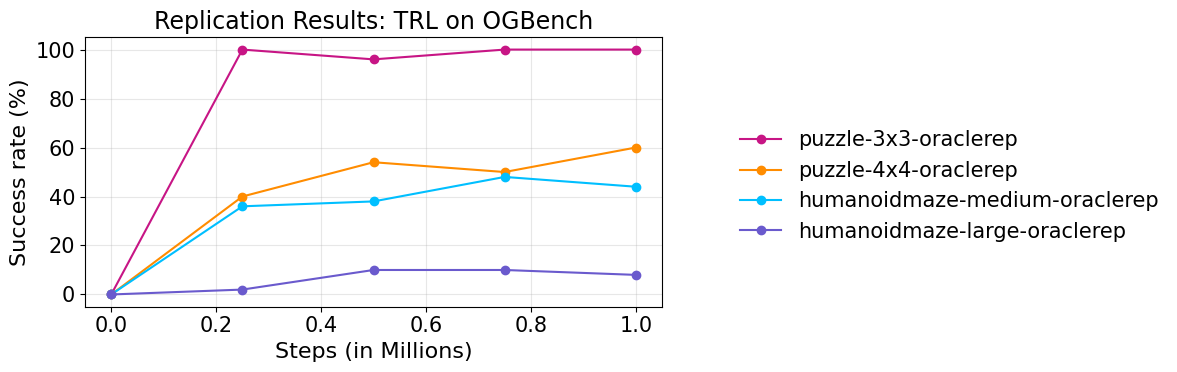

In [ ]:
main_curves = get_run_curves(MAIN_RUN_IDS, handcoded=MAIN_RUNS_USE_HANDCODED, handcoded_metrics=MAIN_HANDCODED)
plot_curves(curves=main_curves, title='Replication Results: TRL on OGBench', filename = 'main_results.pdf')

  [ok]   puzzle-4x5 (1nu92u1b): 4 eval points, final=4.0%
  [ok]   puzzle-4x6 (4wuityz1): 4 eval points, final=0.0%
  [ok]   humanoidmaze-giant (l6kekdsq): 4 eval points, final=48.0%


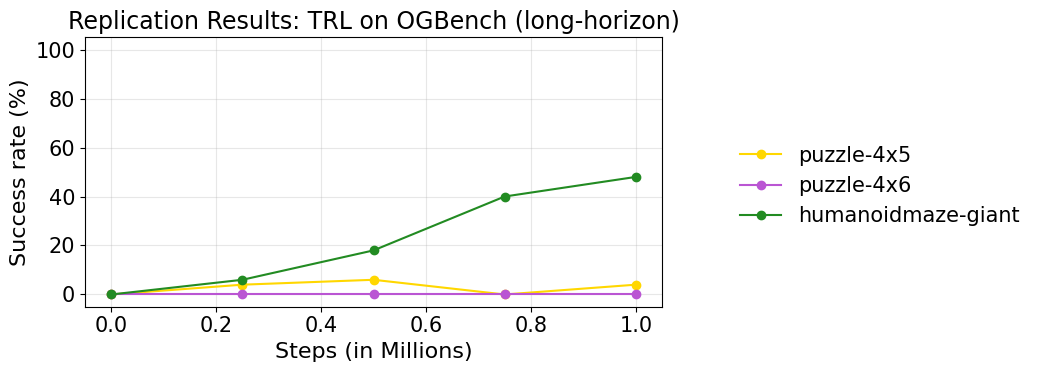

In [ ]:
long_curves = get_run_curves(LONG_RUN_IDS)
plot_curves(curves=long_curves, title='Replication Results: TRL on OGBench (long-horizon)', filename='long_results.pdf')

  [ok]   pointmaze-teleport-navigate (ecj8fid2): 4 eval points, final=38.0%
  [ok]   antmaze-large-stitch  (4ha1lat2): 4 eval points, final=2.0%


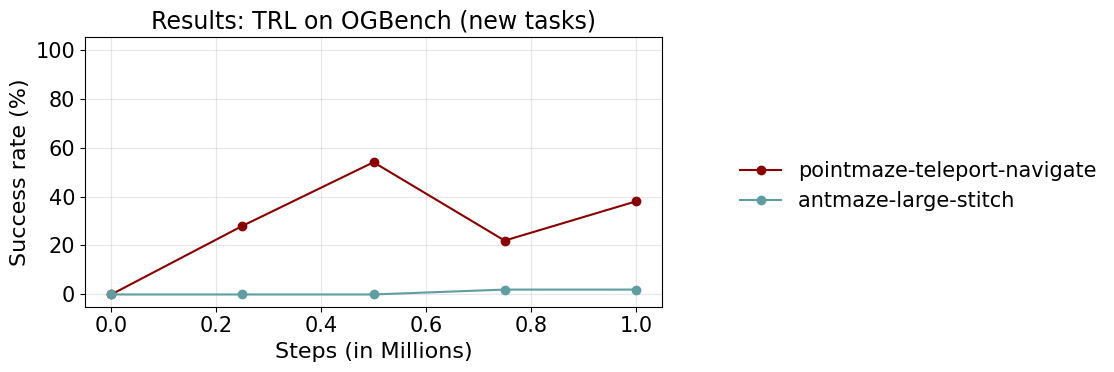

In [ ]:
new_curves = get_run_curves(NEW_RUN_IDS)
plot_curves(curves=new_curves, title='Results: TRL on OGBench (new tasks)', filename='new_results.pdf')

## Per-task breakdown for the 4 main runs

OGBench envs each have 5 sub-tasks. Overall success is the mean across them. This grid shows which sub-tasks the agent solves vs not — often the moderate `overall_success` numbers come from solving some sub-tasks well and others not at all, which is a more interesting story than the single mean.

In [ ]:
# Pull per-task curves for each main run. Reuses MAIN_RUN_IDS from earlier.
def get_per_task_curves(run_id_dict):
  N_TASKS = 5
  per_task_curves = {}  # {label: {task_idx: (steps_m, vals_pct)}}

  for label, rid in run_id_dict.items():
      if not rid:
          continue
      per_task_curves[label] = {}
      for t in range(1, N_TASKS + 1):
          metric = f'evaluation/task{t}_success'
          try:
              steps, vals = fetch_run_curve(rid, metric=metric)
          except Exception as e:
              print(f'  [error] {label} task{t}: {e}')
              continue
          if steps is None:
              continue
          per_task_curves[label][t] = (steps / 1e6, vals * 100)
      print(f'  [ok] {label}: pulled {len(per_task_curves[label])} tasks')

      # Also pull overall performance curve and embed it in per_task_curves
      try:
          steps_overall, vals_overall = fetch_run_curve(rid, metric='evaluation/overall_success')
          if steps_overall is not None:
              per_task_curves[label]['overall'] = (steps_overall / 1e6, vals_overall * 100)
              print(f'  [ok] {label}: pulled overall success')
          else:
              print(f'  [warn] {label}: overall success data not available')
      except Exception as e:
          print(f'  [error] {label} overall: {e}')

  return per_task_curves

In [ ]:
def plot_task_curves(per_task_curves, filename):
  N_TASKS = 5
  envs_with_data = [lbl for lbl in per_task_curves
                    if per_task_curves[lbl]]
  n_envs = len(envs_with_data)

  fig, axes = plt.subplots(1, n_envs, figsize=(4 * n_envs, 3.5),
                          sharey=True, squeeze=False)
  axes = axes[0]

  for ax, label in zip(axes, envs_with_data):
      for t in range(1, N_TASKS + 1):
          if t in per_task_curves[label]:
              steps_m, vals = per_task_curves[label][t]
              steps_m = np.insert(steps_m, 0, 0)
              vals = np.insert(vals, 0, 0)
              marker = 'o' if len(steps_m) <= 10 else None
              ax.plot(steps_m, vals, marker=marker,
                      label=f'Task {t}', color=TASK_COLORS[t-1], linestyle='--') # Changed to dashed

      # Plot overall curve if it exists in the per_task_curves for this label
      if 'overall' in per_task_curves[label]:
          steps_m_overall, vals_overall = per_task_curves[label]['overall']
          # Ensure overall curve also starts from 0,0 for consistent plotting
          steps_m_overall_plot = np.insert(steps_m_overall, 0, 0)
          vals_overall_plot = np.insert(vals_overall, 0, 0)

          marker_overall = 'o' if len(steps_m_overall_plot) <= 10 else None
          ax.plot(steps_m_overall_plot, vals_overall_plot, marker=marker_overall,
                  linestyle='-', color='black', linewidth=2, label='Overall') # Changed to solid

      ax.set_title(label)
      ax.set_xlabel('Steps (M)')
      ax.set_ylim(-5, 105)
      ax.grid(True, alpha=0.3)

  axes[0].set_ylabel('Success rate (%)')

  # Shared legend to the right of the rightmost panel
  handles, labels = axes[-1].get_legend_handles_labels()
  fig.legend(handles, labels, loc='center left',
            bbox_to_anchor=(1.0, 0.5), frameon=False)

  plt.tight_layout()
  plt.savefig(filename, bbox_inches='tight')
  plt.show()

  [ok] puzzle-3x3-oraclerep: pulled 5 tasks
  [ok] puzzle-3x3-oraclerep: pulled overall success
  [ok] puzzle-4x4-oraclerep: pulled 5 tasks
  [ok] puzzle-4x4-oraclerep: pulled overall success
  [ok] humanoidmaze-medium-oraclerep: pulled 5 tasks
  [ok] humanoidmaze-medium-oraclerep: pulled overall success
  [ok] humanoidmaze-large-oraclerep: pulled 5 tasks
  [ok] humanoidmaze-large-oraclerep: pulled overall success


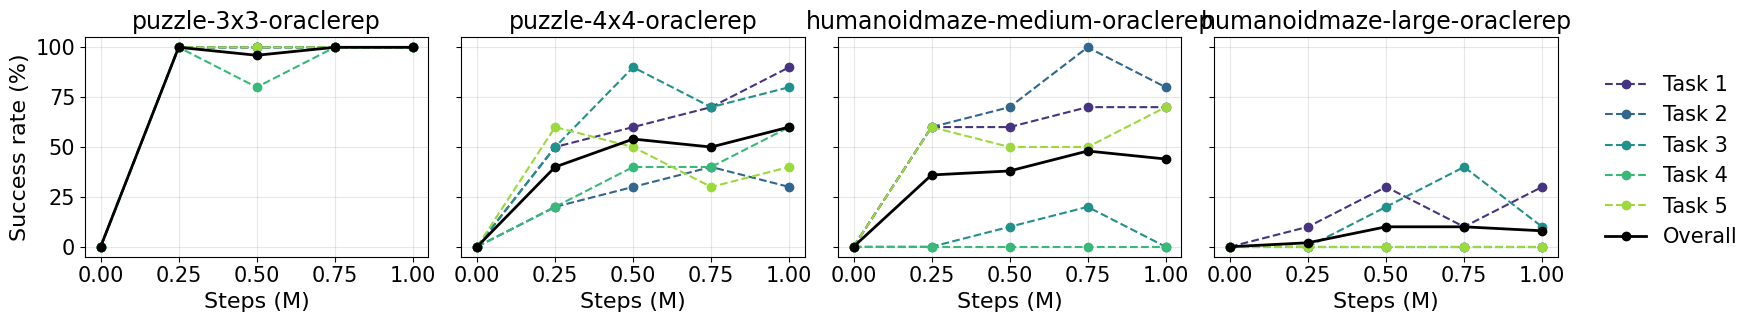

In [ ]:
per_task_data = get_per_task_curves(MAIN_RUN_IDS)
plot_task_curves(per_task_data, filename = 'per_task_by_env.pdf')

  [ok] puzzle-4x5: pulled 5 tasks
  [ok] puzzle-4x5: pulled overall success
  [ok] puzzle-4x6: pulled 5 tasks
  [ok] puzzle-4x6: pulled overall success
  [ok] humanoidmaze-giant: pulled 5 tasks
  [ok] humanoidmaze-giant: pulled overall success


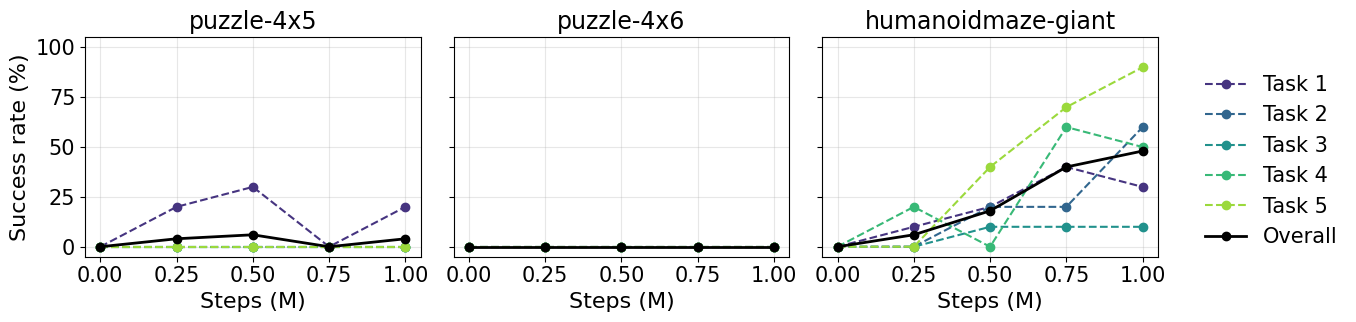

In [ ]:
long_task_data = get_per_task_curves(LONG_RUN_IDS)
plot_task_curves(long_task_data, filename = 'per_task_by_env_long.pdf')

  [ok] pointmaze-teleport-navigate: pulled 5 tasks
  [ok] pointmaze-teleport-navigate: pulled overall success
  [ok] antmaze-large-stitch : pulled 5 tasks
  [ok] antmaze-large-stitch : pulled overall success


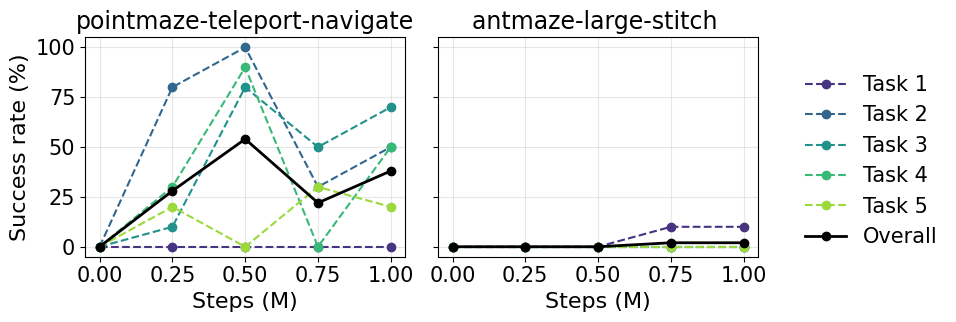

In [ ]:
new_task_data = get_per_task_curves(NEW_RUN_IDS)
plot_task_curves(new_task_data, filename = 'per_task_by_env_new.pdf')

## Critic diagnostics (appendix figure)

Three panels: critic loss, pred max, pred min. Rules out critic collapse — important context after the May 5/6 puzzle-4x4-oraclerep run that converged to constant predictions before Tate's oracle fixes.

In [ ]:
# Pull critic curves for each main run
def get_critic_curves(run_id_dict):
  critic_curves = {}  # {label: {metric_short: (steps_m, vals)}}
  CRITIC_METRICS = {
      'critic_loss': 'training/critic/critic_loss',
      'pred_max':    'training/critic/pred_max',
      'pred_min':    'training/critic/pred_min',
  }

  for label, rid in run_id_dict.items():
      if not rid:
          continue
      critic_curves[label] = {}
      for short, metric in CRITIC_METRICS.items():
          try:
              steps, vals = fetch_run_curve(rid, metric=metric)
          except Exception as e:
              print(f'  [error] {label} {short}: {e}')
              continue
          if steps is None:
              continue
          # Critic metrics keep raw scale (no *100), unlike eval success rates
          critic_curves[label][short] = (steps / 1e6, vals)
      print(f'  [ok] {label}: pulled {len(critic_curves[label])} critic metrics')
  return critic_curves

In [ ]:
def plot_critic_curves(critic_curves, filename):
  fig, axes = plt.subplots(1, 3, figsize=(15, 4))
  titles = {'critic_loss': 'Critic loss', 'pred_max': 'Critic prediction (max)', 'pred_min': 'Critic prediction (min)'}

  for ax, short in zip(axes, ['critic_loss', 'pred_max', 'pred_min']):
      for label, metrics in critic_curves.items():
          if short not in metrics:
              continue
          steps_m, vals = metrics[short]
          ax.plot(steps_m, vals, label=label, color=ENV_COLORS.get(label))
      ax.set_title(titles[short])
      ax.set_xlabel('Steps (in Millions)')
      ax.grid(True, alpha=0.3)

  # Shared legend to the right of the rightmost panel
  handles, labels = axes[-1].get_legend_handles_labels()
  fig.legend(handles, labels, loc='center left',
            bbox_to_anchor=(1.0, 0.5), frameon=False)

  plt.tight_layout()
  plt.savefig(filename, bbox_inches='tight')
  plt.show()

  [ok] puzzle-3x3-oraclerep: pulled 3 critic metrics
  [ok] puzzle-4x4-oraclerep: pulled 3 critic metrics
  [ok] humanoidmaze-medium-oraclerep: pulled 3 critic metrics
  [ok] humanoidmaze-large-oraclerep: pulled 3 critic metrics


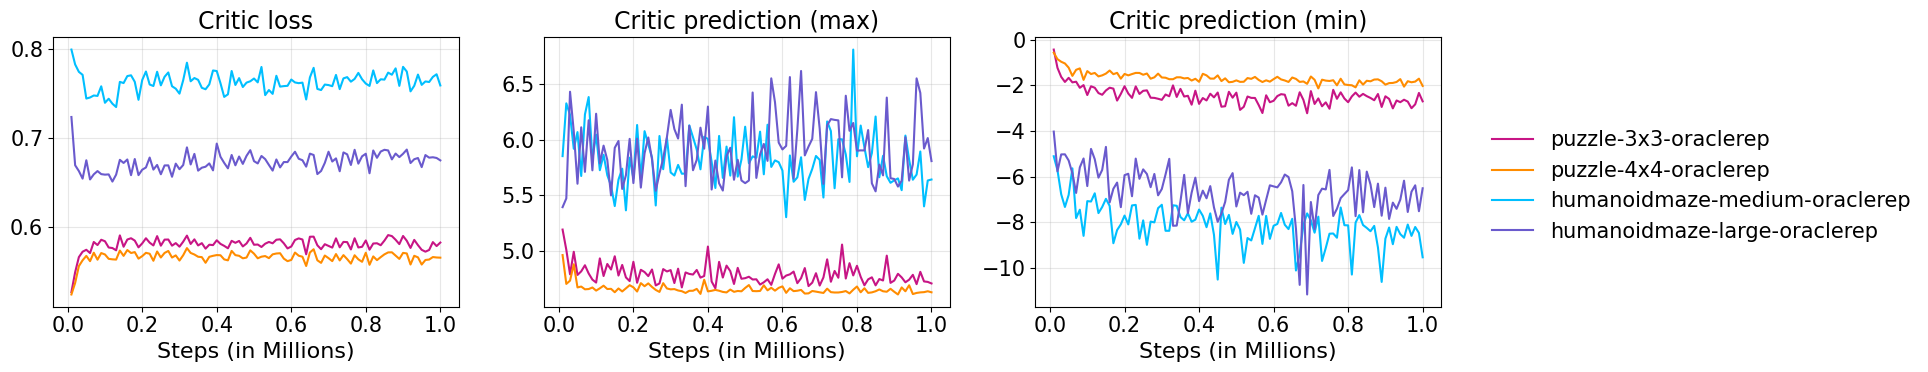

In [ ]:
main_critic_curve = get_critic_curves(MAIN_RUN_IDS)
plot_critic_curves(main_critic_curve, filename = 'critic_diagnostics.pdf')

  [ok] puzzle-4x5: pulled 3 critic metrics
  [ok] puzzle-4x6: pulled 3 critic metrics
  [ok] humanoidmaze-giant: pulled 3 critic metrics


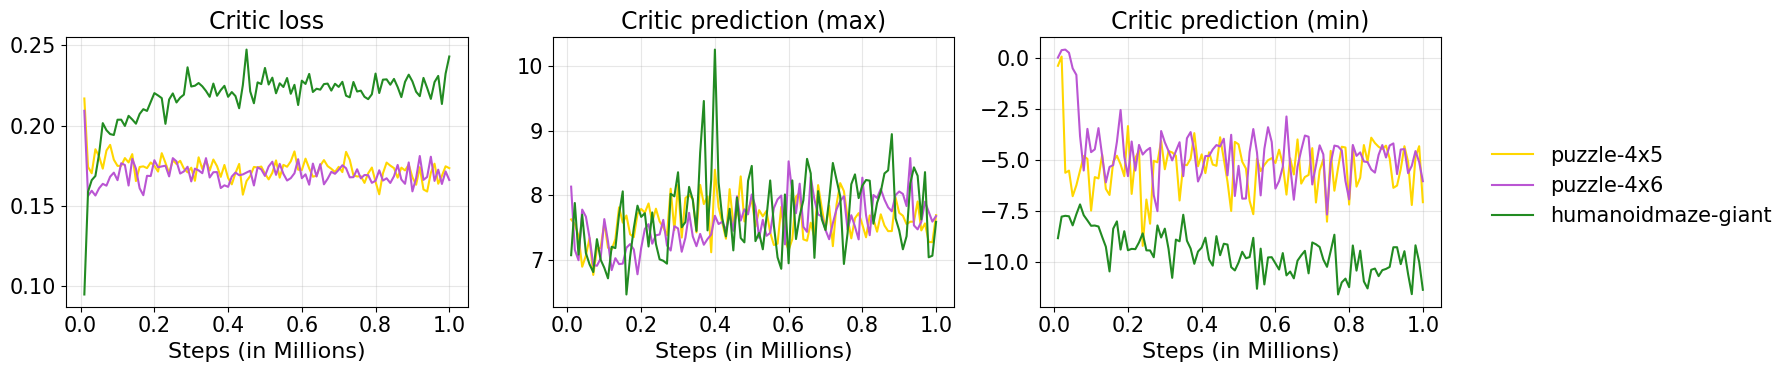

In [ ]:
long_critic_curve = get_critic_curves(LONG_RUN_IDS)
plot_critic_curves(long_critic_curve, filename = 'critic_diagnostics_long.pdf')

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


  [ok] pointmaze-teleport-navigate: pulled 3 critic metrics
  [ok] antmaze-large-stitch : pulled 3 critic metrics


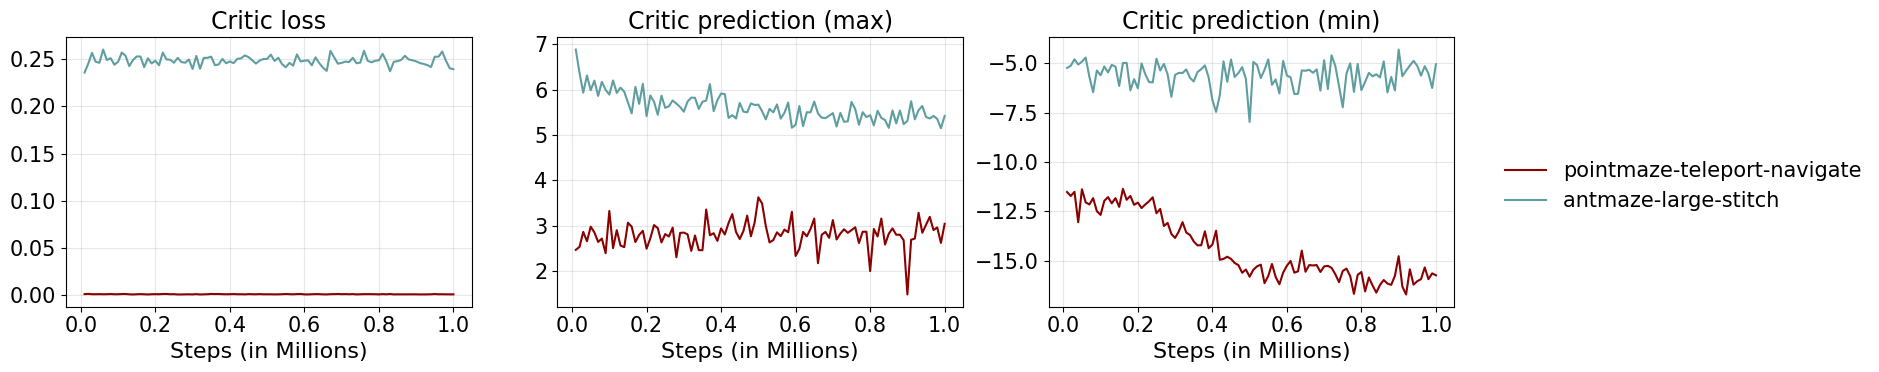

In [ ]:
new_critic_curve = get_critic_curves(NEW_RUN_IDS)
plot_critic_curves(new_critic_curve, filename = 'critic_diagnostics_new.pdf')

## Train vs validation critic loss (appendix figure)

Confirms training and validation losses track each other → no overfitting on offline data. One panel per env.

In [ ]:
# Pull train and val critic loss for each main run
def get_train_val_curves(run_id_dict):
  train_val_curves = {}  # {label: {'train': (s,v), 'val': (s,v)}}

  for label, rid in run_id_dict.items():
      if not rid:
          continue
      train_val_curves[label] = {}
      for kind, metric in [('train', 'training/critic/critic_loss'),
                          ('val',   'validation/critic/critic_loss')]:
          try:
              steps, vals = fetch_run_curve(rid, metric=metric)
          except Exception as e:
              print(f'  [error] {label} {kind}: {e}')
              continue
          if steps is None:
              continue
          train_val_curves[label][kind] = (steps / 1e6, vals)
      print(f'  [ok] {label}: pulled {list(train_val_curves[label].keys())}')
  return train_val_curves

In [ ]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def lighten(color, amount=0.5):
    """Return a lighter (pastel) version of a named color.
    amount=0 returns the original; amount=1 returns white."""
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1 - rgb) * amount)

In [ ]:
def plot_train_val_curves(train_val_curves, filename):
  envs_with_tv = [lbl for lbl in train_val_curves if train_val_curves[lbl]]
  n = len(envs_with_tv)

  # 2x2 layout: lay out envs in a grid, row-major. Falls back to 1xN if fewer than 4 envs.
  if n == 4:
      nrows, ncols = 2, 2
  else:
      nrows, ncols = 1, n

  fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)
  flat_axes = axes.flatten()

  for ax, label in zip(flat_axes, envs_with_tv):
      curves = train_val_curves[label]
      val_color = ENV_COLORS.get(label)
      train_color = lighten(val_color, amount=0.5)
      if 'train' in curves:
          s, v = curves['train']
          ax.plot(s, v, color=train_color)
      if 'val' in curves:
          s, v = curves['val']
          ax.plot(s, v, color=val_color)
      ax.set_title(label)
      ax.set_xlabel('Steps (in Millions)')
      ax.set_ylabel('Critic loss')
      ax.grid(True, alpha=0.3)

  # Hide any leftover axes if envs_with_tv has fewer entries than the grid
  for ax in flat_axes[len(envs_with_tv):]:
      ax.set_visible(False)

  # Custom gray-toned legend showing the train/val pattern, not env identity
  LEGEND_BASE = 'dimgray'
  legend_handles = [
      Line2D([0], [0], color=lighten(LEGEND_BASE, amount=0.5), label='train'),
      Line2D([0], [0], color=LEGEND_BASE, label='val'),
  ]
  fig.legend(handles=legend_handles, loc='center left',
            bbox_to_anchor=(1.0, 0.5), frameon=False)

  plt.tight_layout()
  plt.savefig(filename, bbox_inches='tight')
  plt.show()

  [ok] puzzle-3x3-oraclerep: pulled ['train', 'val']
  [ok] puzzle-4x4-oraclerep: pulled ['train', 'val']
  [ok] humanoidmaze-medium-oraclerep: pulled ['train', 'val']
  [ok] humanoidmaze-large-oraclerep: pulled ['train', 'val']


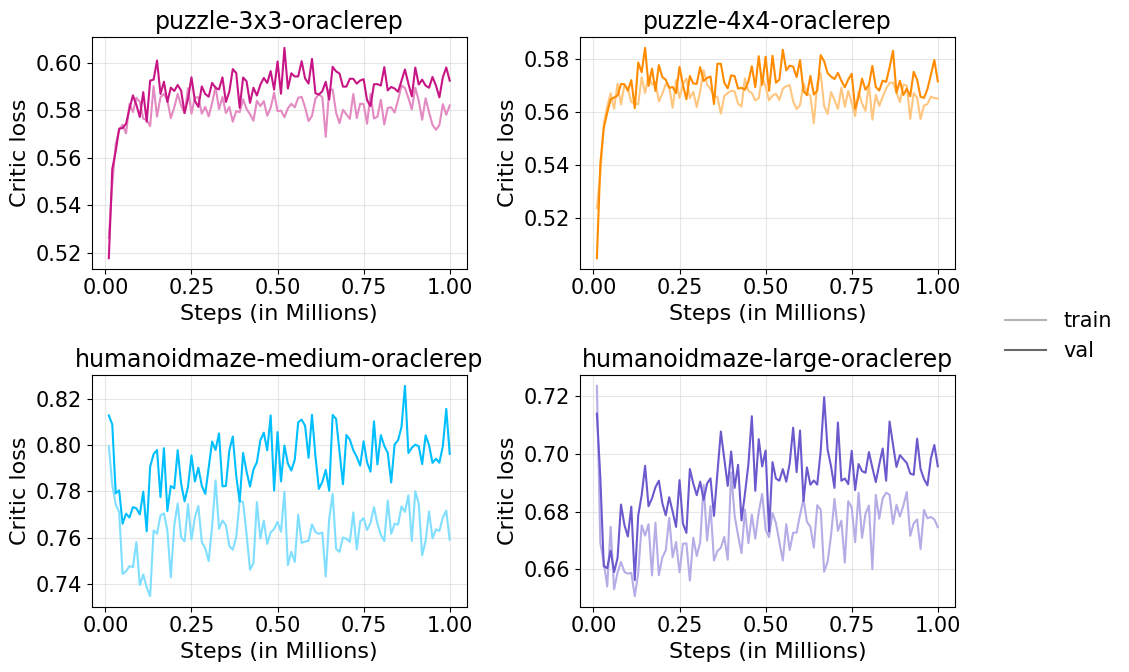

In [ ]:
main_train_val_curve = get_train_val_curves(MAIN_RUN_IDS)
plot_train_val_curves(main_train_val_curve, filename = 'train_val_loss.pdf')

  [ok] puzzle-4x5: pulled ['train', 'val']
  [ok] puzzle-4x6: pulled ['train', 'val']
  [ok] humanoidmaze-giant: pulled ['train', 'val']


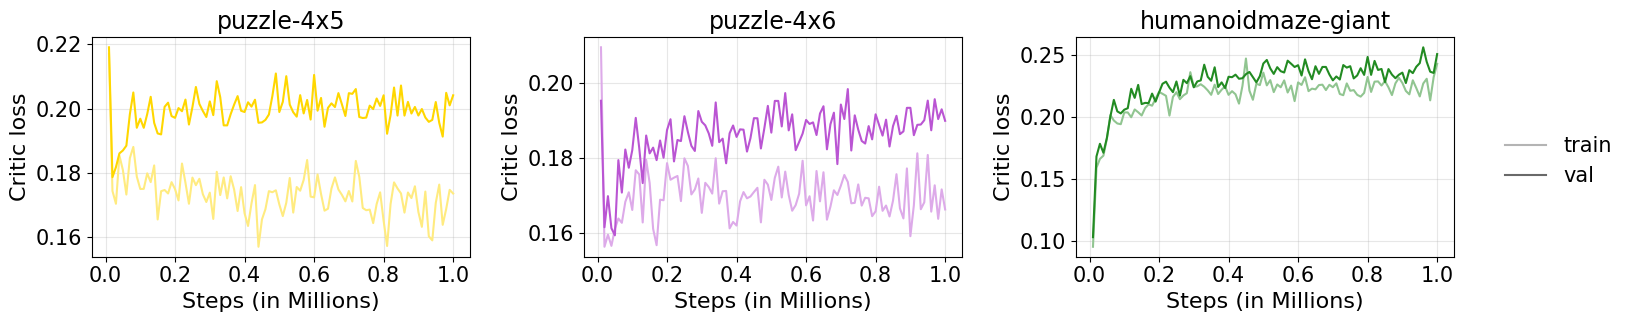

In [ ]:
long_train_val_curve = get_train_val_curves(LONG_RUN_IDS)
plot_train_val_curves(long_train_val_curve, filename = 'train_val_loss_long.pdf')

  [ok] pointmaze-teleport-navigate: pulled ['train', 'val']
  [ok] antmaze-large-stitch : pulled ['train', 'val']


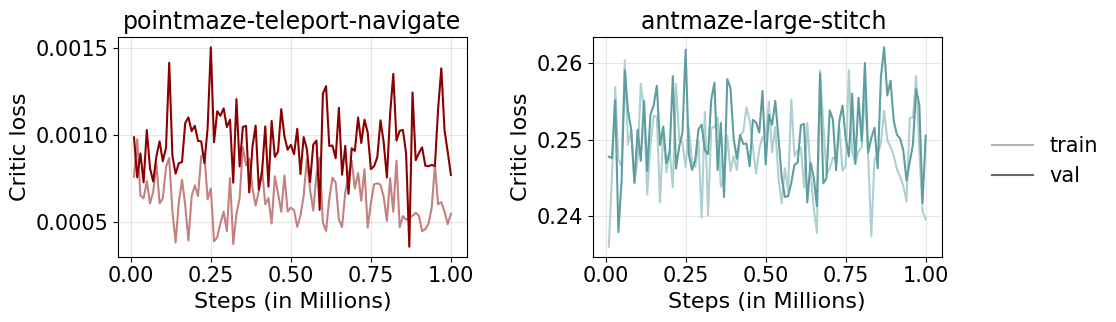

In [ ]:
new_train_val_curve = get_train_val_curves(NEW_RUN_IDS)
plot_train_val_curves(new_train_val_curve, filename = 'train_val_loss_new.pdf')